# Assignment 3 – Experiment Analysis
Analysis of travel time and delay across 5 bridge breakdown scenarios on the Bangladesh road network (N1, N2 + side roads).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
IMG_DIR = '../img'
os.makedirs(IMG_DIR, exist_ok=True)

# Load all scenario data
scenarios = {}
for i in range(5):
    name = f'scenario {i}'
    path = f'../experiment/{name}.csv'
    scenarios[name] = pd.read_csv(path)
    print(f'{name}: {len(scenarios[name])} trips')

# Combine into single DataFrame
df_all = pd.concat(scenarios.values(), ignore_index=True)
df_all['travel_time_hrs'] = df_all['travel_time'] / 60
df_all['total_waiting_time_hrs'] = df_all['total_waiting_time'] / 60
print(f'\nTotal trips: {len(df_all)}')

scenario 0: 251978 trips
scenario 1: 251961 trips
scenario 2: 251513 trips
scenario 3: 249615 trips
scenario 4: 245440 trips

Total trips: 1250507


## 1. Summary Statistics per Scenario

In [2]:
summary = df_all.groupby('scenario').agg(
    trips=('travel_time', 'count'),
    mean_travel_min=('travel_time', 'mean'),
    median_travel_min=('travel_time', 'median'),
    std_travel_min=('travel_time', 'std'),
    max_travel_min=('travel_time', 'max'),
    mean_wait_min=('total_waiting_time', 'mean'),
    median_wait_min=('total_waiting_time', 'median'),
    max_wait_min=('total_waiting_time', 'max'),
    pct_delayed=('total_waiting_time', lambda x: (x > 0).mean() * 100),
).round(1)
summary = summary.sort_index()
print(summary.to_string())

             trips  mean_travel_min  median_travel_min  std_travel_min  max_travel_min  mean_wait_min  median_wait_min  max_wait_min  pct_delayed
scenario                                                                                                                                         
scenario 0  251978            202.1              177.0           135.5             609            0.0              0.0             0          0.0
scenario 1  251961            202.6              180.0           135.5             609            0.5              0.0            59          2.4
scenario 2  251513            211.8              181.0           145.9             766           10.4              0.0           176         27.8
scenario 3  249615            264.0              231.0           184.0             989           64.1             44.0           398         79.1
scenario 4  245440            370.4              306.0           280.0            1778          174.7            131.0      

## 2. Travel Time Distribution – Boxplot by Scenario

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_97801/1982163876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='scenario', y='travel_time_hrs', ax=ax,


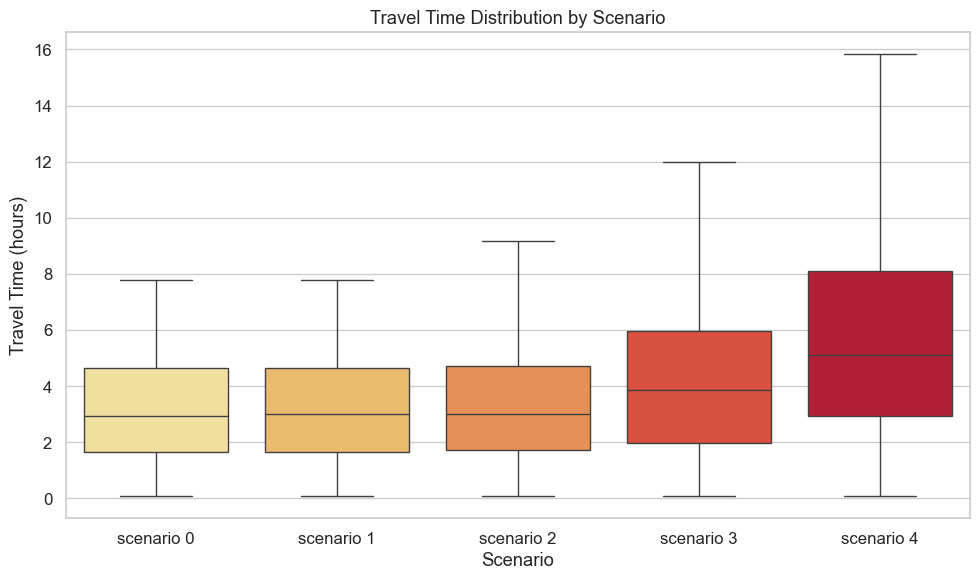

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_all, x='scenario', y='travel_time_hrs', ax=ax,
            order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', showfliers=False)
ax.set_xlabel('Scenario')
ax.set_ylabel('Travel Time (hours)')
ax.set_title('Travel Time Distribution by Scenario')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_travel_time.png'), dpi=150)
plt.show()

## 3. Waiting Time Distribution – Boxplot by Scenario

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_97801/1220246795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_delayed, x='scenario', y='total_waiting_time_hrs', ax=ax,


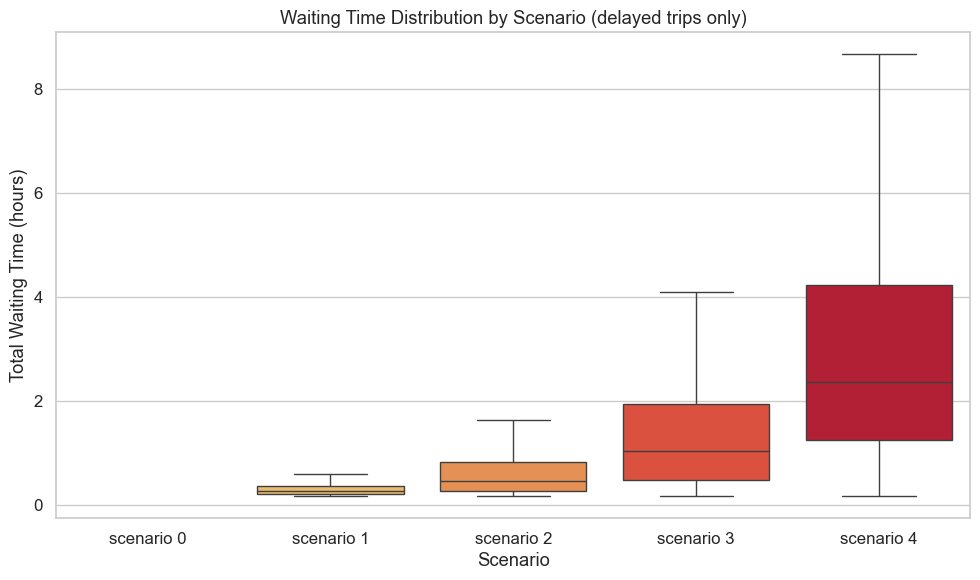

In [4]:
# Only include trips that experienced delay
df_delayed = df_all[df_all['total_waiting_time'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_delayed, x='scenario', y='total_waiting_time_hrs', ax=ax,
            order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', showfliers=False)
ax.set_xlabel('Scenario')
ax.set_ylabel('Total Waiting Time (hours)')
ax.set_title('Waiting Time Distribution by Scenario (delayed trips only)')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_waiting_time.png'), dpi=150)
plt.show()

## 4. Travel Time Histogram – Scenario 0 vs Scenario 4

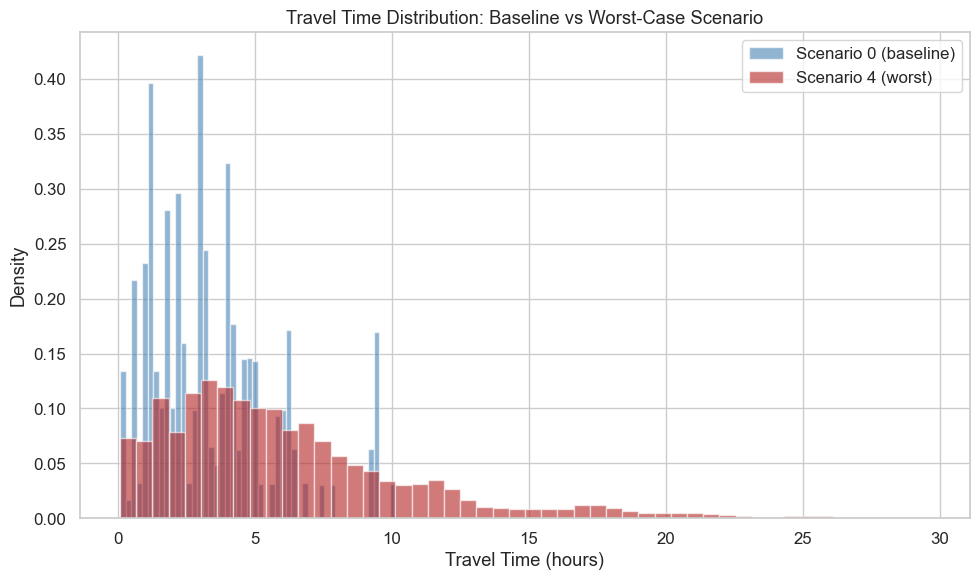

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for scen, color, label in [('scenario 0', 'steelblue', 'Scenario 0 (baseline)'),
                            ('scenario 4', 'firebrick', 'Scenario 4 (worst)')]:
    data = df_all[df_all['scenario'] == scen]['travel_time_hrs']
    ax.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Travel Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Travel Time Distribution: Baseline vs Worst-Case Scenario')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'histogram_travel_time_s0_vs_s4.png'), dpi=150)
plt.show()

## 5. Mean Travel Time per Replication – Variability Across Seeds

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_97801/3886715759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rep_means, x='scenario', y='mean_travel', ax=ax,


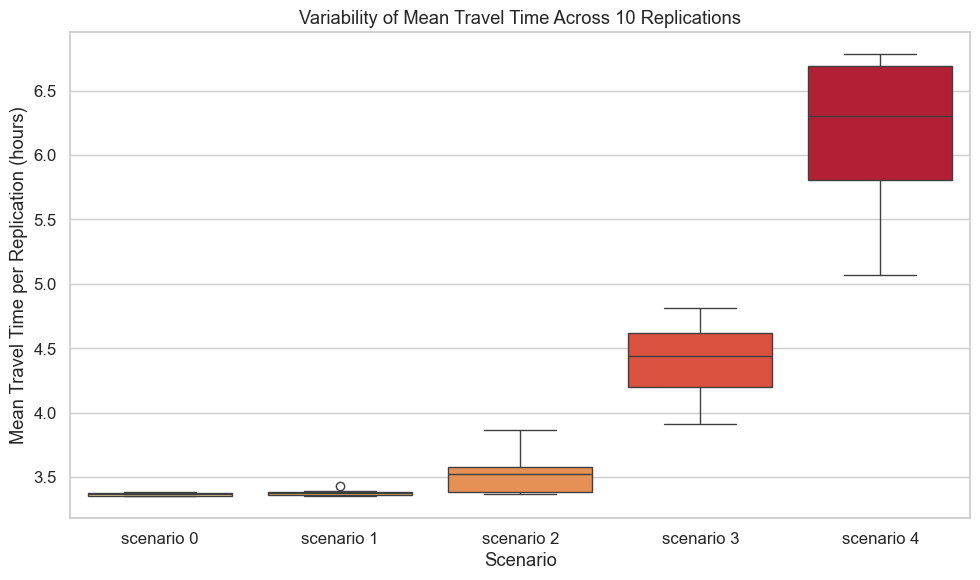

In [6]:
rep_means = df_all.groupby(['scenario', 'replication']).agg(
    mean_travel=('travel_time_hrs', 'mean'),
    mean_wait=('total_waiting_time_hrs', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=rep_means, x='scenario', y='mean_travel', ax=ax,
            order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd')
ax.set_xlabel('Scenario')
ax.set_ylabel('Mean Travel Time per Replication (hours)')
ax.set_title('Variability of Mean Travel Time Across 10 Replications')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_replication_variability.png'), dpi=150)
plt.show()

## 6. Mean Travel Time by Origin Road per Scenario

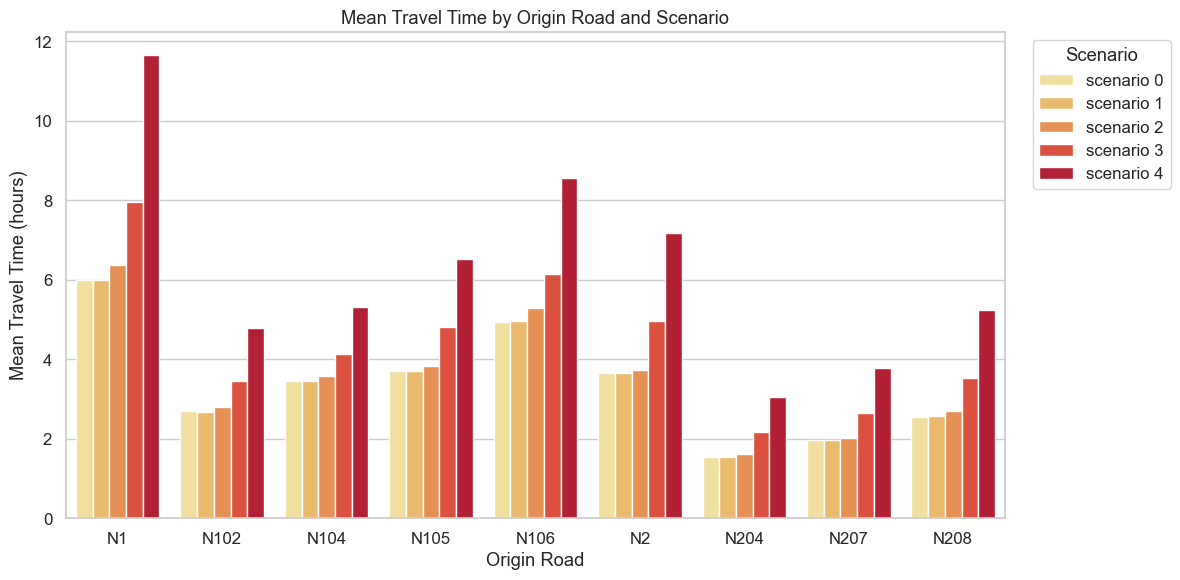

In [7]:
road_means = df_all.groupby(['scenario', 'origin_road'])['travel_time_hrs'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=road_means, x='origin_road', y='travel_time_hrs', hue='scenario',
            hue_order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', ax=ax)
ax.set_xlabel('Origin Road')
ax.set_ylabel('Mean Travel Time (hours)')
ax.set_title('Mean Travel Time by Origin Road and Scenario')
ax.legend(title='Scenario', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'barplot_travel_by_road.png'), dpi=150)
plt.show()

## 7. Scenario Comparison – Bar Chart (Mean Travel Time & Waiting Time)

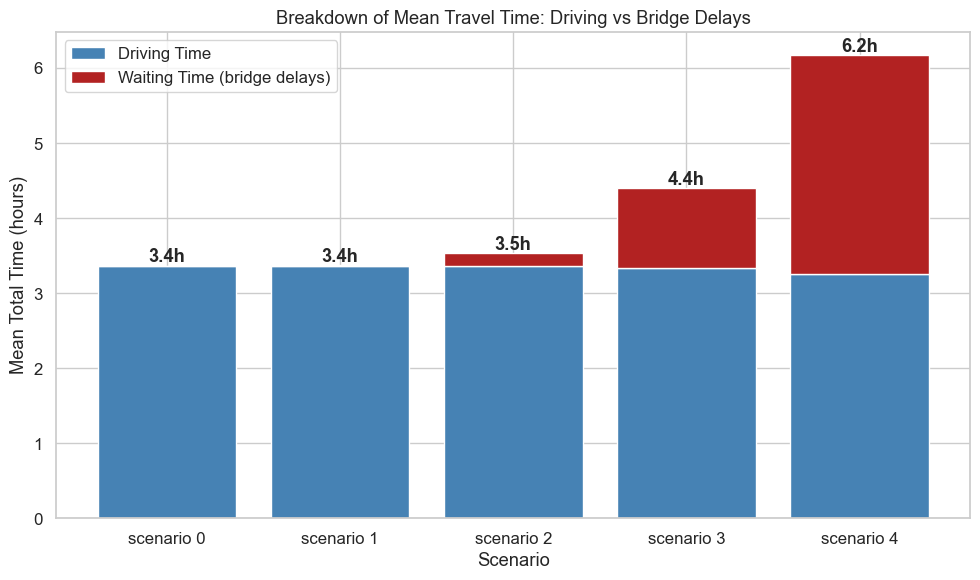

In [8]:
scenario_order = [f'scenario {i}' for i in range(5)]
means = df_all.groupby('scenario').agg(
    driving_time=('travel_time_hrs', 'mean'),
    waiting_time=('total_waiting_time_hrs', 'mean')
).reindex(scenario_order)
means['pure_driving'] = means['driving_time'] - means['waiting_time']

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(range(5), means['pure_driving'], label='Driving Time', color='steelblue')
bars2 = ax.bar(range(5), means['waiting_time'], bottom=means['pure_driving'],
               label='Waiting Time (bridge delays)', color='firebrick')
ax.set_xticks(range(5))
ax.set_xticklabels(scenario_order)
ax.set_xlabel('Scenario')
ax.set_ylabel('Mean Total Time (hours)')
ax.set_title('Breakdown of Mean Travel Time: Driving vs Bridge Delays')
ax.legend()

# Add total labels
for i, total in enumerate(means['driving_time']):
    ax.text(i, total + 0.05, f'{total:.1f}h', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'stacked_bar_driving_vs_waiting.png'), dpi=150)
plt.show()

## 8. Percentage of Delayed Trips per Scenario

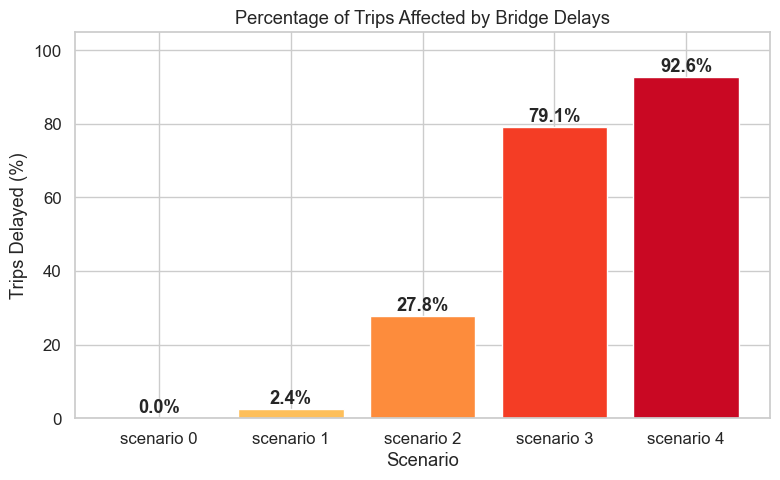

In [9]:
pct_delayed = df_all.groupby('scenario')['total_waiting_time'].apply(
    lambda x: (x > 0).mean() * 100
).reindex(scenario_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(5), pct_delayed, color=sns.color_palette('YlOrRd', 5))
ax.set_xticks(range(5))
ax.set_xticklabels(scenario_order)
ax.set_xlabel('Scenario')
ax.set_ylabel('Trips Delayed (%)')
ax.set_title('Percentage of Trips Affected by Bridge Delays')
ax.set_ylim(0, 105)

for i, pct in enumerate(pct_delayed):
    ax.text(i, pct + 1.5, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'bar_pct_delayed.png'), dpi=150)
plt.show()

## 9. Summary Table for Report

In [10]:
breakdown_labels = {
    'scenario 0': 'A=0%, B=0%, C=0%, D=0%',
    'scenario 1': 'A=0%, B=0%, C=0%, D=5%',
    'scenario 2': 'A=0%, B=0%, C=5%, D=10%',
    'scenario 3': 'A=0%, B=5%, C=10%, D=20%',
    'scenario 4': 'A=5%, B=10%, C=20%, D=40%',
}

report_table = df_all.groupby('scenario').agg(
    total_trips=('travel_time', 'count'),
    mean_travel_hrs=('travel_time_hrs', 'mean'),
    median_travel_hrs=('travel_time_hrs', 'median'),
    mean_wait_hrs=('total_waiting_time_hrs', 'mean'),
    max_wait_hrs=('total_waiting_time_hrs', 'max'),
    pct_delayed=('total_waiting_time', lambda x: (x > 0).mean() * 100),
    mean_bridges=('bridges_passed', 'mean'),
).round(2)

report_table['breakdown_probs'] = report_table.index.map(breakdown_labels)
report_table = report_table.reindex(scenario_order)
print(report_table.to_string())

            total_trips  mean_travel_hrs  median_travel_hrs  mean_wait_hrs  max_wait_hrs  pct_delayed  mean_bridges            breakdown_probs
scenario                                                                                                                                      
scenario 0       251978             3.37               2.95           0.00          0.00         0.00         98.51     A=0%, B=0%, C=0%, D=0%
scenario 1       251961             3.38               3.00           0.01          0.98         2.41         98.53     A=0%, B=0%, C=0%, D=5%
scenario 2       251513             3.53               3.02           0.17          2.93        27.79         98.40    A=0%, B=0%, C=5%, D=10%
scenario 3       249615             4.40               3.85           1.07          6.63        79.09         98.11   A=0%, B=5%, C=10%, D=20%
scenario 4       245440             6.17               5.10           2.91         20.45        92.64         96.87  A=5%, B=10%, C=20%, D=40%